<div align="center">

# 5º PROJETO

| Disciplina | Semestre | Docente | Horário |
| :---: | :---: | :---: | :---: |
| PAM0466 - SISTEMAS INTELIGENTES | 2026.1 | PEDRO THIAGO VALÉRIO DE SOUZA | 3M23 4M45 |

| Discente | Matrícula |
| :---: | :---: |
| ELTON CAIO VIEIRA DE LIMA | 2020010673 |
| LUCAS VIERES ARAÚJO FARIAS | 2025022531 |

</div>

<hr>

## ATIVIDADES

1. Preparação dos dados: carregue os arquivos KDDTrain+.txt e KDDTest+.txt com o `pandas`, atribuindo
nomes às colunas a seguinte lista de rótulos:

```
col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "attack_type", "difficulty_level"
]
```

As duas últimas colunas refere-se à saída (tipo de ataque e nível de dificuldade, mas essa última deve ser descartada). Aplique *one-hot encoding* nos três atributos categóricos (`protocol type`, `service`, `flag`). Em seguida, binarize o rótulo (normal →0; qualquer ataque →1) e normalize todos os atributos numéricos com 𝑍-score usando apenas as estatísticas do conjunto de treino.

In [28]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler


col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "attack_type", "difficulty_level"
]


train_df = pd.read_csv(
    "../dataset/KDDTrain+.txt",
    names=col_names
)

test_df = pd.read_csv(
    "../dataset/KDDTest+.txt",
    names=col_names
)


print("Treino:")
print(train_df.head())

print("\nTeste:")
print(test_df.head())

Treino:
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2     

Remoção da coluna dificulty_level:

In [29]:

train_df.drop("difficulty_level", axis=1, inplace=True)
test_df.drop("difficulty_level", axis=1, inplace=True)

Binarização dos rótulos:

In [30]:
train_df["attack_type"] = train_df["attack_type"].apply(
    lambda x: 0 if x == "normal" else 1
)

test_df["attack_type"] = test_df["attack_type"].apply(
    lambda x: 0 if x == "normal" else 1
)

Aplicando one-hot:

In [31]:
categorical_columns = [
    "protocol_type",
    "service",
    "flag"
]

train_df = pd.get_dummies(
    train_df,
    columns=categorical_columns
)

test_df = pd.get_dummies(
    test_df,
    columns=categorical_columns
)

Normalização dos dados:

In [32]:
train_df, test_df = train_df.align(
    test_df,
    join='left',
    axis=1,
    fill_value=0
)


X_train = train_df.drop("attack_type", axis=1)
y_train = train_df["attack_type"]

X_test = test_df.drop("attack_type", axis=1)
y_test = test_df["attack_type"]

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Verificação da quantidade de ataques entre treino e teste, somente para validar se a separação foi feita corretamente:

In [33]:
print("Formato X_train:", X_train.shape)
print("Formato X_test:", X_test.shape)

print("Quantidade de ataques no treino:")
print(y_train.value_counts())

print("Quantidade de ataques no teste:")
print(y_test.value_counts())

Formato X_train: (125973, 122)
Formato X_test: (22544, 122)
Quantidade de ataques no treino:
attack_type
0    67343
1    58630
Name: count, dtype: int64
Quantidade de ataques no teste:
attack_type
1    12833
0     9711
Name: count, dtype: int64


2. Implementação da MLP em PyTorch: crie uma classe `MLP` herdando de `nn.Module`. A função de perda deve ser `BCEWithLogitsLoss`. Implemente o método `forward` e instancie o modelo, o otimizador Adam e a função de perda. Encapsule os dados em `TensorDataset` e utilize um `DataLoader` com *mini-batches* de tamanho 256.


In [34]:
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [35]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

Minibatches:

In [36]:
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

Classe MLP e modelo instanciado utilizando a função de ativação ReLU:

In [37]:
class MLP(nn.Module):

    def __init__(self, input_size):

        super(MLP, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)

        )

    def forward(self, x):

        return self.network(x)


input_size = X_train.shape[1]

model = MLP(input_size)


criterion = nn.BCEWithLogitsLoss()


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=122, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


3. Treinamento e monitoramento: treine a MLP por 50 épocas registrando a *loss* de treino a cada época. Reserve 20% do conjunto de treino como validação (sem embaralhamento após a divisão) e registre também a *loss* de validação. Ao final, plote as duas curvas na mesma figura. A escolha topológica da rede (número de neurônios por camada oculta, número de camadas ocultas e função de ativação) é de sua responsabilidade. Para isso, recomenda-se testar várias topologias de rede, verificando-se o desempenho no conjunto de validação. Verifique a necessidade de parada antecipada durante o processo de treinamento.\
**Atenção:** para o neurônio da camada de saída, não utilize função de ativação, pois será usada a função de perda *BCEWithLogitsLoss*.

In [38]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import torch.optim as optim

Época 1/50 | Loss treino: 0.0882 | Loss validação: 0.0310
Época 2/50 | Loss treino: 0.0273 | Loss validação: 0.0227
Época 3/50 | Loss treino: 0.0205 | Loss validação: 0.0202
Época 4/50 | Loss treino: 0.0181 | Loss validação: 0.0163
Época 5/50 | Loss treino: 0.0167 | Loss validação: 0.0163
Época 6/50 | Loss treino: 0.0152 | Loss validação: 0.0159
Época 7/50 | Loss treino: 0.0145 | Loss validação: 0.0136
Época 8/50 | Loss treino: 0.0134 | Loss validação: 0.0145
Época 9/50 | Loss treino: 0.0129 | Loss validação: 0.0137
Época 10/50 | Loss treino: 0.0119 | Loss validação: 0.0138
Época 11/50 | Loss treino: 0.0122 | Loss validação: 0.0140
Época 12/50 | Loss treino: 0.0112 | Loss validação: 0.0124
Época 13/50 | Loss treino: 0.0112 | Loss validação: 0.0127
Época 14/50 | Loss treino: 0.0109 | Loss validação: 0.0129
Época 15/50 | Loss treino: 0.0110 | Loss validação: 0.0153
Época 16/50 | Loss treino: 0.0104 | Loss validação: 0.0130
Early stopping na época 17


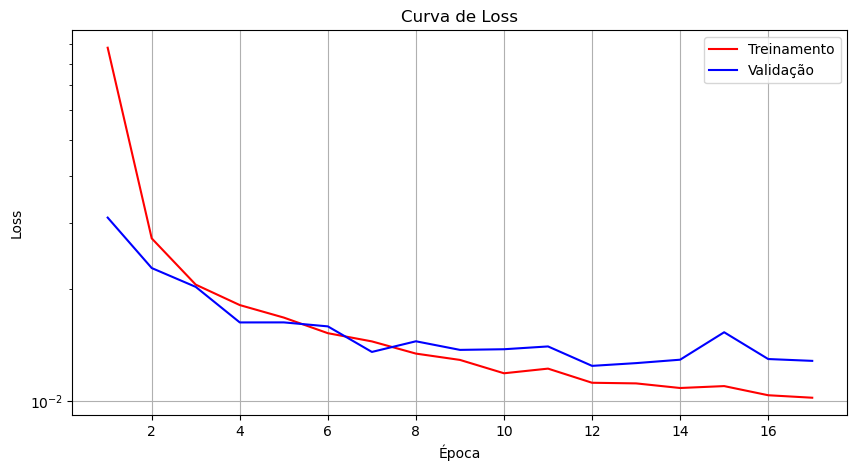

In [39]:
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    shuffle=False
)

X_train_split = torch.tensor(X_train_split, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train_split = torch.tensor(y_train_split.values, dtype=torch.float32)
y_val = torch.tensor(y_val.values, dtype=torch.float32)

train_ds = TensorDataset(X_train_split, y_train_split)

train_loader = DataLoader(
    train_ds,
    batch_size=256,
    shuffle=True
)


model = MLP(input_size=X_train.shape[1])
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


epochs = 50
patience = 5

best_val_loss = np.inf
best_weights = None

train_loss = []
val_loss = []

stop_epoch = epochs
epochs_no_improve = 0


for epoch in range(epochs):

    model.train()
    epoch_train_loss = 0.0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()
        outputs = model(batch_X).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    train_loss.append(
        epoch_train_loss / len(train_loader)
    )

    model.eval()

    with torch.no_grad():

        val_predictions = model(X_val).squeeze()
        validation_loss = criterion(
            val_predictions,
            y_val
        ).item()

        val_loss.append(validation_loss)


    if val_loss[-1] < best_val_loss:

        best_val_loss = val_loss[-1]
        best_weights = {
            k: v.clone()
            for k, v in model.state_dict().items()
        }

        epochs_no_improve = 0

    else:

        epochs_no_improve += 1

        if epochs_no_improve >= patience:
            stop_epoch = epoch + 1
            print(f"Early stopping na época {stop_epoch}")
            break

    print(
        f'Época {epoch+1}/{epochs} | '
        f'Loss treino: {train_loss[-1]:.4f} | '
        f'Loss validação: {val_loss[-1]:.4f}'
    )


model.load_state_dict(best_weights)
epoch_vector = np.arange(1, len(train_loss)+1)

plt.figure(figsize=(10,5))

plt.semilogy(
    epoch_vector,
    train_loss,
    'r',
    label='Treinamento'
)

plt.semilogy(
    epoch_vector,
    val_loss,
    'b',
    label='Validação'
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de Loss")
plt.grid()
plt.legend()
plt.show()

4. Avaliação final: utilizando a arquitetura de melhor desempenho na validação, avalie o modelo no conjunto de teste KDDTest+.txt. Aplique um limiar de 0,5 sobre a saída da sigmoide para obter os rótulos preditos e gere a matriz de confusão. Calcule e reporte acurácia, precisão, *recall* e F1-score. Em um sistema de detecção de intrusão em produção, qual tipo de erro é mais crítico: um falso negativo (ataque classificado como normal) ou um falso positivo (conexão normal classificada como ataque)? Como essa escolha afeta a definição do limiar de decisão?

=== RESULTADOS DA AVALIAÇÃO FINAL (ATIVIDADE 4) ===
Acurácia : 0.7875 (78.75%)
Precisão : 0.9273 (92.73%)
Recall   : 0.6800 (68.00%)
F1-Score : 0.7847 (78.47%)



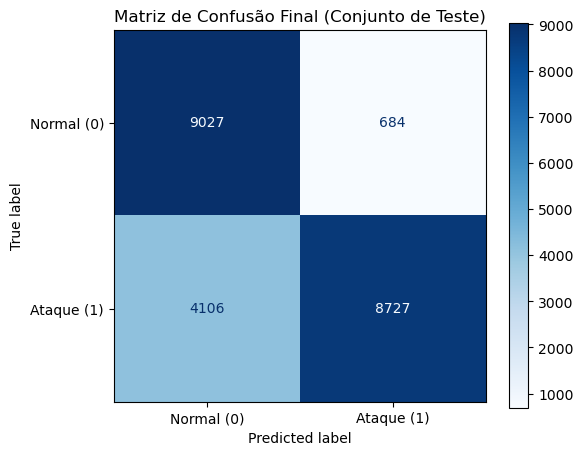

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

model.eval()

y_true_list = []
y_pred_list = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        
        outputs = model(batch_X).squeeze(-1) 
        
        probs = torch.sigmoid(outputs)
        
        preds = (probs >= 0.5).int()
        
        y_pred_list.extend(preds.numpy())
        y_true_list.extend(batch_y.numpy())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

cm = confusion_matrix(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Acurácia : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precisão : {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall   : {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1-Score : {f1:.4f} ({f1 * 100:.2f}%)\n")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Normal (0)', 'Ataque (1)']
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusão Final (Conjunto de Teste)')
plt.grid(False)
plt.show()

Em um sistema de detecção de intrusão, o erro mais crítico é o falso negativo, pois ele permite que ameaças reais invadam a rede e comprometam a infraestrutura, enquanto o falso positivo causa apenas transtornos operacionais com alarmes falsos. Para evitar que intrusões passem despercebidas, a definição do limiar de decisão é ajustada para baixo (por exemplo, de 0,5 para 0,2 ou 0,3), tornando o modelo mais sensível e priorizando a métrica de Recall. Com essa escolha, garante-se o bloqueio da grande maioria dos ataques, aceitando-se como consequência um aumento tolerável no volume de falsos positivos para a equipe de segurança analisar.